# TASK 2

# Exploratory Data Analysis (EDA) 


In [1]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("books_multiple_pages.csv")

# Clean Price
df["Price"] = df["Price"].str.replace(r"[^\d.]", "", regex=True)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Convert Rating
rating_map = {"One":1,"Two":2,"Three":3,"Four":4,"Five":5}
df["Rating"] = df["Rating"].map(rating_map)

print(df.head())

                                   Title  Price  Rating
0                   A Light in the Attic  51.77       3
1                     Tipping the Velvet  53.74       1
2                             Soumission  50.10       1
3                          Sharp Objects  47.82       4
4  Sapiens: A Brief History of Humankind  54.23       5


In [3]:
# Basic info
print(df.info())

# Data types
print(df.dtypes)

# Shape
print(df.shape)

# Columns
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   60 non-null     object 
 1   Price   60 non-null     float64
 2   Rating  60 non-null     int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.5+ KB
None
Title      object
Price     float64
Rating      int64
dtype: object
(60, 3)
Index(['Title', 'Price', 'Rating'], dtype='object')


In [4]:
print(df.describe())

           Price     Rating
count  60.000000  60.000000
mean   35.002667   3.000000
std    14.553082   1.507046
min    12.840000   1.000000
25%    22.040000   1.750000
50%    33.485000   3.000000
75%    50.142500   4.000000
max    57.310000   5.000000


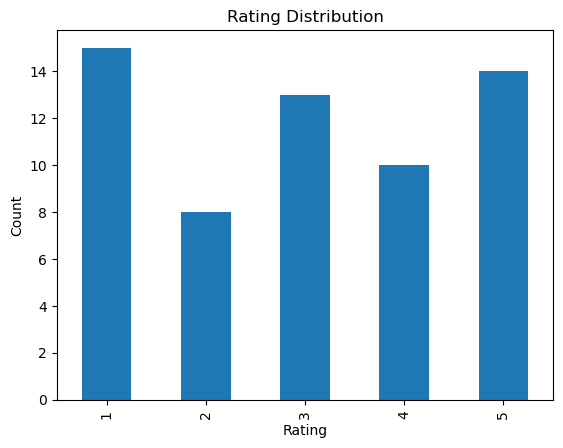

In [5]:
df["Rating"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()

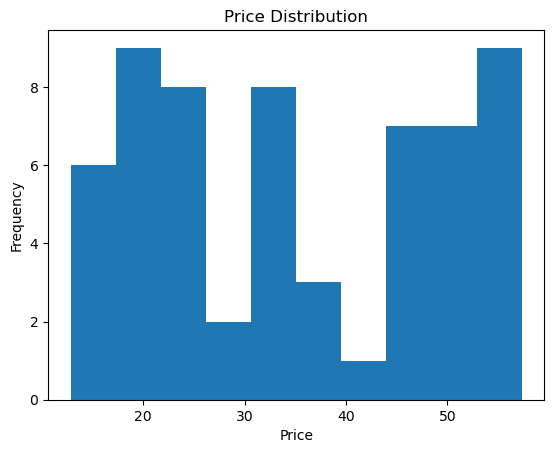

In [6]:
plt.hist(df["Price"], bins=10)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

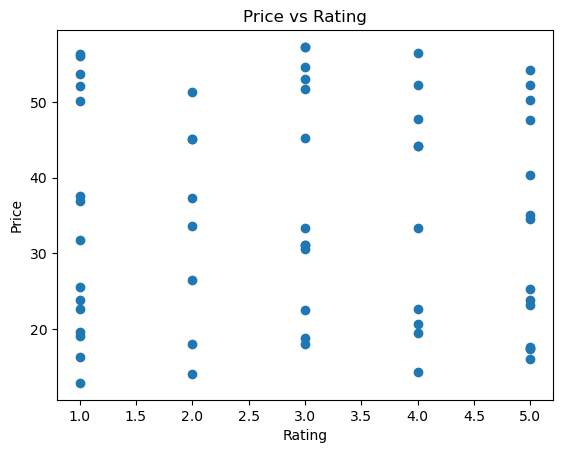

In [7]:
plt.scatter(df["Rating"], df["Price"])
plt.xlabel("Rating")
plt.ylabel("Price")
plt.title("Price vs Rating")
plt.show()

Rating
1    34.311333
2    33.867500
3    38.808462
4    35.526000
5    32.484286
Name: Price, dtype: float64


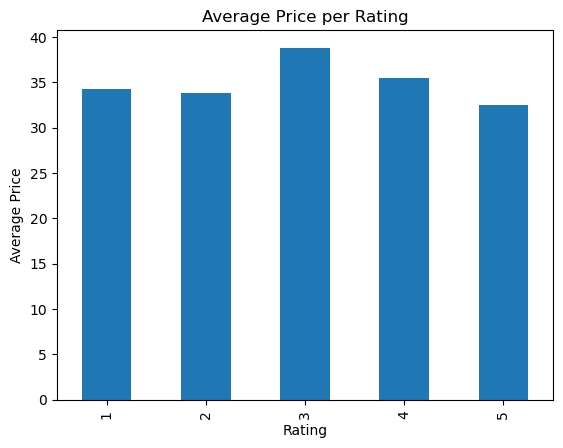

In [8]:
avg_price = df.groupby("Rating")["Price"].mean()
print(avg_price)

avg_price.plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Average Price")
plt.title("Average Price per Rating")
plt.show()

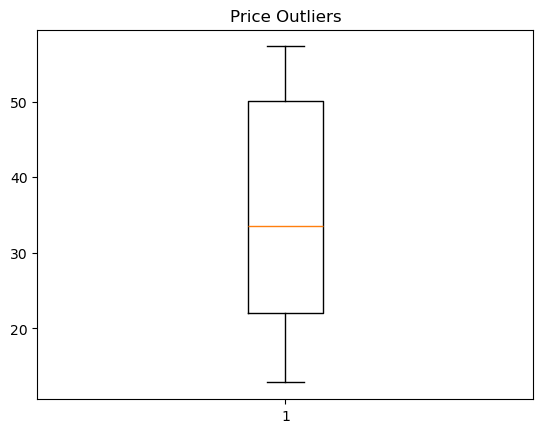

In [9]:
plt.boxplot(df["Price"])
plt.title("Price Outliers")
plt.show()

In [10]:
print(df.isnull().sum())

Title     0
Price     0
Rating    0
dtype: int64


In [11]:
print(df.duplicated().sum())

0


In [12]:
print(df[df["Price"] <= 0])

Empty DataFrame
Columns: [Title, Price, Rating]
Index: []


In [13]:
print(df.corr(numeric_only=True))

           Price    Rating
Price   1.000000 -0.027403
Rating -0.027403  1.000000


In [14]:
df.to_csv("books_cleaned.csv", index=False)